# VAE Training Notebook — Mixed Precision

Identical to normal precision training file except inclusion of
'amp.autocast()' and 'GradScaler' to make the training mixed precision

1-Setup and Imports to adjust your root directory location

2-Configuration to select between models and choose hyperparams

AMP is not supported on CPU

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1 — Setup & Imports

In [ ]:
import sys, os, time, json
from pathlib import Path

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ── Ensure project root is importable ──────────────────────
PROJECT_ROOT = Path('/content/drive/MyDrive/Bayes_Project')  # assumes notebook is in train/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch:      {torch.__version__}')
print(f'CUDA:         {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:          {torch.cuda.get_device_name(0)}')


Project root: /content/drive/MyDrive/Bayes_Project
PyTorch:      2.10.0+cu128
CUDA:         True
GPU:          Tesla T4


In [ ]:
from data.dataloader import get_dataloaders, IMAGE_SIZE
from models.base import get_model, MODEL_REGISTRY

# ── Import model modules so they self-register ─────────────
# CHANGE POINT: add one import line per new model file.
import models.vae       # noqa: F401
import models.conv_vae  # noqa: F401
import models.vq_vae    # noqa: F401

from train.train_utils import (
    MetricTracker,
    RunLog,
    Timer,
    compute_image_metrics,
    save_checkpoint,
    load_checkpoint,
)
from outputs.plotting import (
    plot_loss,
    plot_all_metrics,
    plot_reconstructions,
    plot_samples,
)

print('Available models:', list(MODEL_REGISTRY.keys()))


Available models: ['vae', 'conv_vae', 'vq_vae']


## 2 — Configuration

All hyperparameters live here. Nothing else in the notebook needs editing for a standard run.

In [ ]:
# Model
MODEL_KEY       = 'conv_vae'      # 'vae' | 'conv_vae' | 'vq_vae'
LATENT_DIM      = 64
HIDDEN_DIMS     = [128, 256]      # linear VAE: neuron counts e.g. [512, 256, 256, 128]
                                  # conv VAE:  channel counts e.g. [32, 64, 128, 256]
KL_WEIGHT       = 1.0             # beta > 1 → beta-VAE
RECON_LOSS_TYPE = 'mse'           # 'bce' or 'mse'

# VQ-VAE specific
NUM_EMBEDDINGS  = 1024             # codebook size K
COMMITMENT_COST = 0.25            # beta on commitment loss
USE_EMA         = True            # EMA codebook updates
EMA_DECAY       = 0.99
KL_ANNEAL_EPOCHS = 20

# DATA
DATASET         = 'cifar10' # 'mnist' | 'fashion_mnist' | 'cifar10'
BATCH_SIZE      = 128
NUM_WORKERS     = 2
DATA_ROOT       = str(PROJECT_ROOT / 'data' / 'raw')

# Training
EPOCHS          = 50
LR              = 1e-3
WEIGHT_DECAY    = 1e-5
SCHEDULER_TYPE  = 'none'          # 'none' | 'cosine' | 'step', not used
STEP_SIZE       = 20              # not used
GAMMA           = 0.5             # not used
PRECISION       = 'mixed'         # logging purposes

# Logging
CHECKPOINT_DIR  = str(PROJECT_ROOT / 'models' / 'checkpoints')
LOG_DIR         = str(PROJECT_ROOT / 'logs')
OUTPUT_DIR      = str(PROJECT_ROOT / 'outputs')
SAVE_EVERY      = 0
RUN_NAME        = "conv_vae_cifar10_mixedprec"            # auto-generated if None

# Misc
SEED            = 42
DEVICE          = None            # None = auto-detect (must be CUDA for AMP)


## 3 — Device & Seed

In [ ]:
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if DEVICE:
    device = torch.device(DEVICE)
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    raise RuntimeError(
        'Mixed precision requires CUDA. '
        'Use train_fp32.ipynb for CPU/MPS training.'
    )

print(f'Device: {device}')
print(f'AMP:    enabled')


Device: cuda
AMP:    enabled


## 4 — Data

In [ ]:
train_loader, test_loader, channels = get_dataloaders(
    dataset_name=DATASET,
    batch_size=BATCH_SIZE,
    data_root=DATA_ROOT,
    num_workers=NUM_WORKERS,
)

print(f'Dataset:      {DATASET}')
print(f'Channels:     {channels}')
print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')


Dataset:      cifar10
Channels:     3
Train batches: 390
Test batches:  79


### Quick data preview

Batch shape: torch.Size([128, 3, 32, 32])  |  dtype: torch.float32
Pixel range:  [0.000, 1.000]


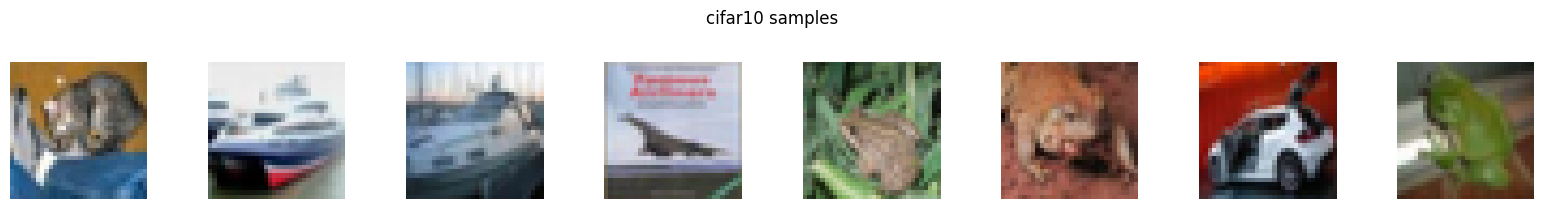

In [ ]:
sample_batch, sample_labels = next(iter(test_loader))
print(f'Batch shape: {sample_batch.shape}  |  dtype: {sample_batch.dtype}')
print(f'Pixel range:  [{sample_batch.min():.3f}, {sample_batch.max():.3f}]')

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    img = sample_batch[i]
    if img.shape[0] == 1:
        axes[i].imshow(img.squeeze(0), cmap='gray')
    else:
        axes[i].imshow(img.permute(1, 2, 0))
    axes[i].axis('off')
plt.suptitle(f'{DATASET} samples', y=1.02)
plt.tight_layout()
plt.show()


## 5 — Model

In [ ]:
model = get_model(
    MODEL_KEY,
    input_channels=channels,
    image_size=IMAGE_SIZE,
    hidden_dims=HIDDEN_DIMS,
    latent_dim=LATENT_DIM,
    kl_weight=KL_WEIGHT,
    recon_loss_type=RECON_LOSS_TYPE,
    # VQ-VAE specific (ignored by other models via **kwargs)
    num_embeddings=NUM_EMBEDDINGS,
    commitment_cost=COMMITMENT_COST,
    use_ema=USE_EMA,
    ema_decay=EMA_DECAY,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model:         {model.model_name}')
print(f'Total params:  {total_params:,}')
print(f'Trainable:     {trainable:,}')
print(f'Extra metrics: {model.extra_metrics}')
print(f'Latent dim:    {model.get_latent_dim()}')


Model:         conv_vae
Total params:  3,760,515
Trainable:     3,760,515
Extra metrics: []
Latent dim:    64


## 6 — Optimizer & Scheduler

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

scheduler = None
if SCHEDULER_TYPE == 'cosine':
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS
    )
elif SCHEDULER_TYPE == 'step':
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=STEP_SIZE, gamma=GAMMA
    )

# Gradscaler
scaler = torch.amp.GradScaler('cuda')

print(f'Optimizer:  Adam (lr={LR}, wd={WEIGHT_DECAY})')
print(f'Scheduler:  {SCHEDULER_TYPE}')
print(f'GradScaler: enabled')


Optimizer:  Adam (lr=0.001, wd=1e-05)
Scheduler:  none
GradScaler: enabled


## 7 — Run Log Initialisation

In [ ]:
dims_tag = '-'.join(str(d) for d in HIDDEN_DIMS)
run_name = RUN_NAME or f'{model.model_name}_{DATASET}_h{dims_tag}_z{LATENT_DIM}_{PRECISION}'

run_log = RunLog(
    model_name=model.model_name,
    dataset=DATASET,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LR,
    latent_dim=LATENT_DIM,
    kl_weight=KL_WEIGHT,
    optimizer_name='Adam',
    scheduler_name=SCHEDULER_TYPE,
    precision=PRECISION,
    device=str(device),
    seed=SEED,
    extra_hparams={
        'hidden_dims': HIDDEN_DIMS,
        'recon_loss': RECON_LOSS_TYPE,
        'weight_decay': WEIGHT_DECAY,
        'num_embeddings': NUM_EMBEDDINGS,
        'commitment_cost': COMMITMENT_COST,
        'use_ema': USE_EMA,
        'kl_anneal_epochs': KL_ANNEAL_EPOCHS,
    },
)

log_path  = Path(LOG_DIR) / f'{run_name}.json'
ckpt_dir  = Path(CHECKPOINT_DIR)
out_dir   = Path(OUTPUT_DIR)

for d in [log_path.parent, ckpt_dir, out_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Run name:    {run_name}')
print(f'Log path:    {log_path}')
print(f'Checkpoints: {ckpt_dir}')


Run name:    conv_vae_cifar10_mixedprec
Log path:    /content/drive/MyDrive/Bayes_Project/logs/conv_vae_cifar10_mixedprec.json
Checkpoints: /content/drive/MyDrive/Bayes_Project/models/checkpoints


## 8 — Training & Evaluation Functions

Key differences from FP32:
- Forward + loss wrapped in `torch.amp.autocast('cuda')`
- `scaler.scale(loss).backward()` instead of `loss.backward()`
- `scaler.step(optimizer)` + `scaler.update()` instead of `optimizer.step()`

In [ ]:
def train_one_epoch(model, loader, optimizer, device, tracker, scaler):
    """Run one training epoch with mixed precision."""
    model.train()
    for batch_data, _ in loader:
        batch_data = batch_data.to(device)
        batch_size = batch_data.size(0)

        # Forward
        with torch.amp.autocast('cuda'):
            model_output = model.forward(batch_data)

        # Loss
        model_output_f32 = {
            k: v.float() if isinstance(v, torch.Tensor) and v.is_floating_point() else v
            for k, v in model_output.items()
        }
        if 'recon' in model_output_f32:
            model_output_f32['recon'] = model_output_f32['recon'].clamp(1e-6, 1 - 1e-6)

        loss_dict = model.loss_function(model_output_f32, batch_data)
        total_loss = loss_dict['total_loss']

        # Backward
        optimizer.zero_grad()
        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Metrics
        with torch.no_grad():
            recon = model_output_f32['recon']
            img_metrics = compute_image_metrics(recon, batch_data)

        extra_dict = {
            k: model_output_f32[k]
            for k in model.extra_metrics
            if k in model_output_f32
        }

        tracker.update(loss_dict, img_metrics, extra_dict, batch_size)


@torch.no_grad()
def evaluate(model, loader, device, tracker):
    """Run evaluation with mixed precision."""
    model.eval()
    for batch_data, _ in loader:
        batch_data = batch_data.to(device)
        batch_size = batch_data.size(0)

        # Forward
        with torch.amp.autocast('cuda'):
            model_output = model.forward(batch_data)

        # Loss
        model_output_f32 = {
            k: v.float() if isinstance(v, torch.Tensor) and v.is_floating_point() else v
            for k, v in model_output.items()
        }
        if 'recon' in model_output_f32:
            model_output_f32['recon'] = model_output_f32['recon'].clamp(1e-6, 1 - 1e-6)

        loss_dict = model.loss_function(model_output_f32, batch_data)

        # Metrics
        recon = model_output_f32['recon']
        img_metrics = compute_image_metrics(recon, batch_data)

        extra_dict = {
            k: model_output_f32[k]
            for k in model.extra_metrics
            if k in model_output_f32
        }

        tracker.update(loss_dict, img_metrics, extra_dict, batch_size)

## 9 — Training Loop

In [ ]:
timer = Timer()
timer.start()
best_loss = float('inf')

live_train_loss = []
live_val_loss   = []

print(f'Starting training for {EPOCHS} epochs (mixed precision) …')
if KL_ANNEAL_EPOCHS > 0 and hasattr(model, 'kl_weight'):
    print(f'KL annealing: 0 → {KL_WEIGHT} over first {KL_ANNEAL_EPOCHS} epochs')
print()

for epoch in range(1, EPOCHS + 1):

    # KL Annealing
    if KL_ANNEAL_EPOCHS > 0 and hasattr(model, 'kl_weight'):
        model.kl_weight = KL_WEIGHT * min(1.0, epoch / KL_ANNEAL_EPOCHS)

    # Train
    train_tracker = MetricTracker(extra_keys=model.extra_metrics)
    train_one_epoch(model, train_loader, optimizer, device, train_tracker, scaler)
    train_summary = train_tracker.summarise()

    # Evaluate
    eval_tracker = MetricTracker(extra_keys=model.extra_metrics)
    evaluate(model, test_loader, device, eval_tracker)
    eval_summary = eval_tracker.summarise()

    if scheduler is not None:
        scheduler.step()

    epoch_record = {
        'epoch': epoch,
        **{f'train_{k}': v for k, v in train_summary.items()},
        **{f'val_{k}': v for k, v in eval_summary.items()},
    }
    run_log.epoch_history.append(epoch_record)

    # Use recon_loss for checkpointing
    val_loss = eval_summary.get('recon_loss', eval_summary.get('total_loss'))
    live_train_loss.append(train_summary['total_loss'])
    live_val_loss.append(eval_summary.get('total_loss', val_loss))

    lr_now = optimizer.param_groups[0]['lr']
    kl_w_str = f'kl_w={model.kl_weight:.3f}  ' if hasattr(model, 'kl_weight') else ''
    print(
        f'  Epoch {epoch:3d}/{EPOCHS}  |  '
        f'train_loss={train_summary["total_loss"]:.4f}  '
        f'val_loss={eval_summary.get("total_loss", val_loss):.4f}  '
        f'psnr={eval_summary.get("psnr", 0):.2f}  '
        f'ssim={eval_summary.get("ssim", 0):.4f}  '
        f'{kl_w_str}'
        f'lr={lr_now:.2e}  '
        f'scale={scaler.get_scale():.0f}'
    )

    # Checkpoint
    is_best = val_loss < best_loss
    if is_best:
        best_loss = val_loss
        run_log.best_epoch = epoch
        run_log.best_total_loss = val_loss
        save_checkpoint(
            model, optimizer, epoch, eval_summary,
            ckpt_dir / f'{run_name}_best.pt',
            scheduler=scheduler,
            extra_state={'scaler_state_dict': scaler.state_dict()},
        )

    if SAVE_EVERY > 0 and epoch % SAVE_EVERY == 0:
        save_checkpoint(
            model, optimizer, epoch, eval_summary,
            ckpt_dir / f'{run_name}_epoch{epoch}.pt',
            scheduler=scheduler,
            extra_state={'scaler_state_dict': scaler.state_dict()},
        )

    # Periodic JSON save (crash safety)
    run_log.total_training_time_sec = timer.elapsed()
    run_log.save(log_path)

# ── Final save ─────────────────────────────────────────────
run_log.total_training_time_sec = timer.elapsed()
run_log.save(log_path)

save_checkpoint(
    model, optimizer, EPOCHS, eval_summary,
    ckpt_dir / f'{run_name}_final.pt',
    scheduler=scheduler,
    extra_state={'scaler_state_dict': scaler.state_dict()},
)

print(f'\nFinished in {run_log.total_training_time_sec:.1f}s')
print(f'Best val_recon_loss={run_log.best_total_loss:.4f} at epoch {run_log.best_epoch}')
print(f'Log: {log_path}')


Starting training for 50 epochs (mixed precision) …
KL annealing: 0 → 1.0 over first 20 epochs

  Epoch   1/50  |  train_loss=82.0010  val_loss=44.6038  psnr=19.59  ssim=0.6702  kl_w=0.050  lr=1.00e-03  scale=256
  Epoch   2/50  |  train_loss=50.8072  val_loss=47.0114  psnr=19.76  ssim=0.6743  kl_w=0.100  lr=1.00e-03  scale=256
  Epoch   3/50  |  train_loss=51.4426  val_loss=48.4070  psnr=19.88  ssim=0.6766  kl_w=0.150  lr=1.00e-03  scale=256
  Epoch   4/50  |  train_loss=53.3493  val_loss=53.3330  psnr=19.53  ssim=0.6731  kl_w=0.200  lr=1.00e-03  scale=256
  Epoch   5/50  |  train_loss=55.5616  val_loss=53.7608  psnr=19.70  ssim=0.6663  kl_w=0.250  lr=1.00e-03  scale=256
  Epoch   6/50  |  train_loss=57.7725  val_loss=56.1560  psnr=19.55  ssim=0.6604  kl_w=0.300  lr=1.00e-03  scale=512
  Epoch   7/50  |  train_loss=59.6680  val_loss=58.5488  psnr=19.39  ssim=0.6480  kl_w=0.350  lr=1.00e-03  scale=512
  Epoch   8/50  |  train_loss=61.6865  val_loss=61.7595  psnr=19.23  ssim=0.6464  kl_

## 10 — Live Loss Curve

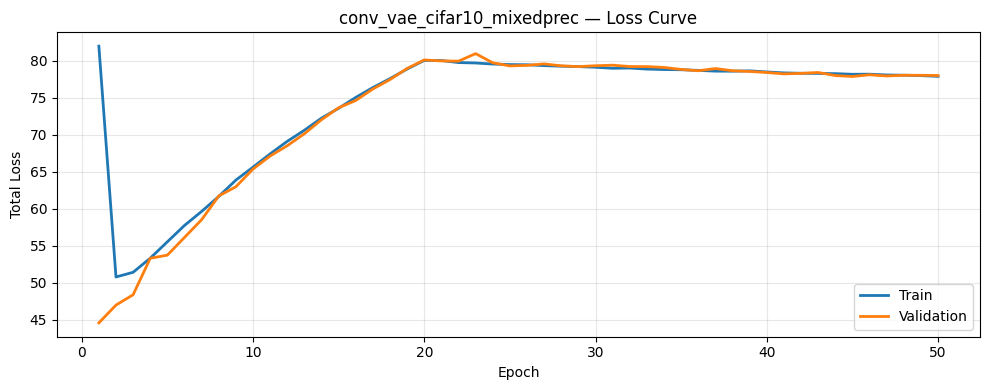

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
epochs_range = range(1, len(live_train_loss) + 1)
ax.plot(epochs_range, live_train_loss, label='Train', linewidth=2)
ax.plot(epochs_range, live_val_loss, label='Validation', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Total Loss')
ax.set_title(f'{run_name} — Loss Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11 — Detailed Metrics (from JSON log)

These use the plotting module, which reads the JSON and auto-detects all metrics  
(including any model-specific extras like codebook usage for VQ-VAE).

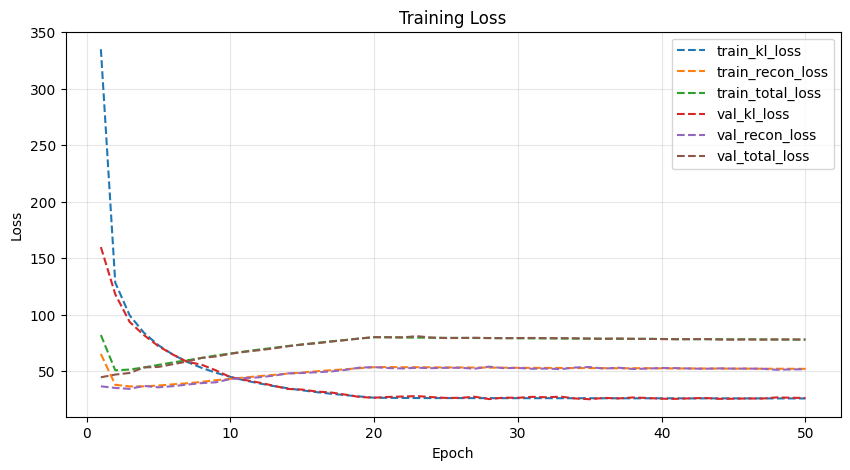

In [ ]:
plot_loss(log_path, save_path=out_dir / f'{run_name}_loss.png', show=True)


## 12 — Reconstructions (Ground Truth vs Model)

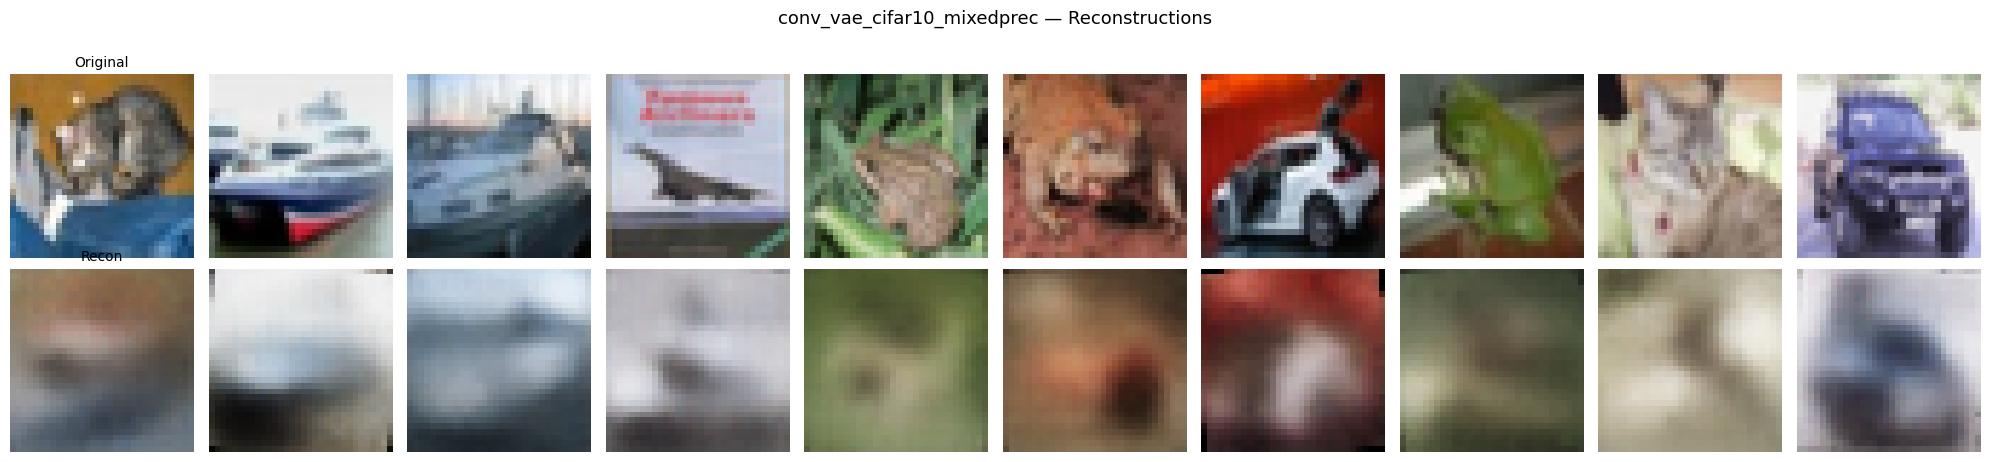

In [ ]:
test_batch, _ = next(iter(test_loader))

plot_reconstructions(
    model,
    test_batch,
    num_images=10,
    save_path=out_dir / f'{run_name}_reconstructions.png',
    title=f'{run_name} — Reconstructions',
    show=True,
)


## 13 — Samples from Prior

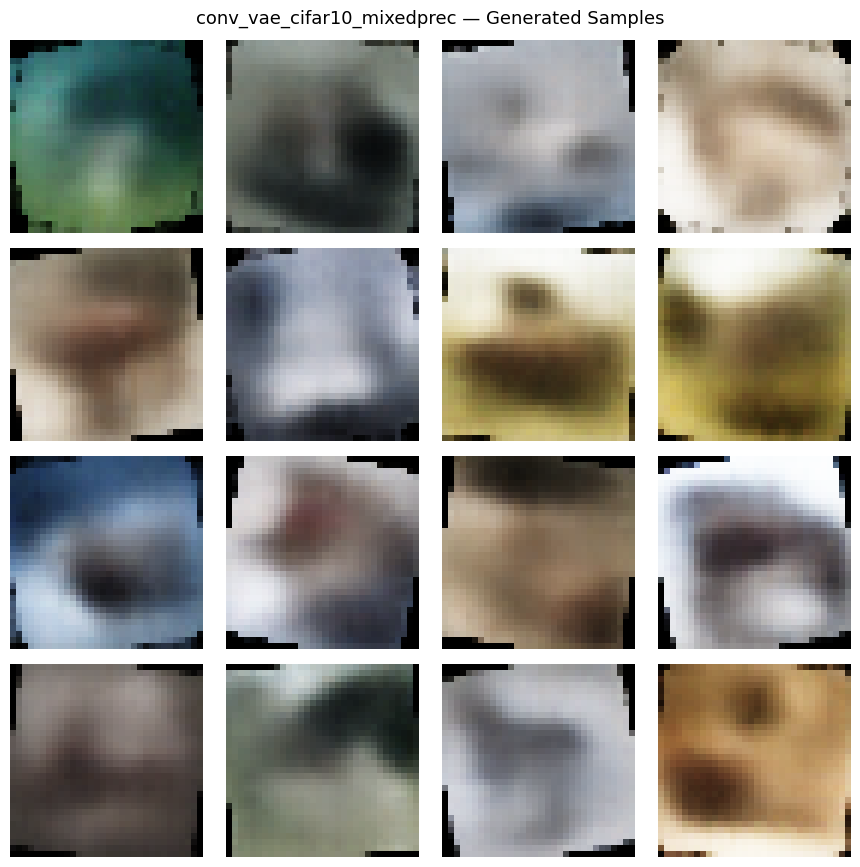

In [ ]:
plot_samples(
    model,
    num_samples=16,
    nrow=4,
    save_path=out_dir / f'{run_name}_samples.png',
    title=f'{run_name} — Generated Samples',
    show=True,
)


## 13b — Codebook Health (VQ-VAE only)

In [ ]:
if hasattr(model, 'quantizer'):
    run_data = run_log.epoch_history

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    epochs_range = range(1, len(run_data) + 1)

    usage = [ep.get('val_codebook_usage', 0) for ep in run_data]
    ax1.plot(epochs_range, usage, color='teal', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Usage (fraction)')
    ax1.set_title('Codebook Usage')
    ax1.set_ylim(0, 1.05)
    ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='ideal')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    perp = [ep.get('val_perplexity', 0) for ep in run_data]
    ax2.plot(epochs_range, perp, color='coral', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Perplexity')
    ax2.set_title('Codebook Perplexity')
    ax2.axhline(y=NUM_EMBEDDINGS, color='gray', linestyle='--', alpha=0.5,
                label=f'max ({NUM_EMBEDDINGS})')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    fig.tight_layout()
    plt.show()

    print(f'Final codebook usage: {usage[-1]:.1%}  '
          f'({int(usage[-1] * NUM_EMBEDDINGS)}/{NUM_EMBEDDINGS} codes active)')
    print(f'Final perplexity:     {perp[-1]:.1f}  (max: {NUM_EMBEDDINGS})')
else:
    print('Not a VQ-VAE model — skipping codebook diagnostics.')


Not a VQ-VAE model — skipping codebook diagnostics.


## 14 — Run Summary

In [ ]:
print('═' * 60)
print(f'  Model:          {run_log.model_name}')
print(f'  Dataset:        {run_log.dataset}')
print(f'  Precision:      {run_log.precision}')
print(f'  Epochs:         {run_log.epochs}')
print(f'  Best epoch:     {run_log.best_epoch}')
print(f'  Best val loss:  {run_log.best_total_loss:.4f}')
print(f'  Training time:  {run_log.total_training_time_sec:.1f}s')
print(f'  Latent dim:     {run_log.latent_dim}')
print(f'  KL weight:      {run_log.kl_weight}')
if KL_ANNEAL_EPOCHS > 0:
    print(f'  KL annealing:   {KL_ANNEAL_EPOCHS} epochs')
print(f'  Device:         {run_log.device}')
print('═' * 60)
print(f'\nJSON log:     {log_path}')
print(f'Best ckpt:    {ckpt_dir / f"{run_name}_best.pt"}')
print(f'Final ckpt:   {ckpt_dir / f"{run_name}_final.pt"}')
print(f'Plots:        {out_dir}')


════════════════════════════════════════════════════════════
  Model:          conv_vae
  Dataset:        cifar10
  Precision:      mixed
  Epochs:         50
  Best epoch:     3
  Best val loss:  34.3705
  Training time:  871.8s
  Latent dim:     64
  KL weight:      1.0
  KL annealing:   20 epochs
  Device:         cuda
════════════════════════════════════════════════════════════

JSON log:     /content/drive/MyDrive/Bayes_Project/logs/conv_vae_cifar10_mixedprec.json
Best ckpt:    /content/drive/MyDrive/Bayes_Project/models/checkpoints/conv_vae_cifar10_mixedprec_best.pt
Final ckpt:   /content/drive/MyDrive/Bayes_Project/models/checkpoints/conv_vae_cifar10_mixedprec_final.pt
Plots:        /content/drive/MyDrive/Bayes_Project/outputs


## (Optional) Load a Checkpoint for Later Inference

Uncomment and run this cell if you restart the kernel.